# Outfield D1 or not Models — Train V2

Split the **hitter** CSV into just the outfielders to do model development on them.

Building out the d1 or not models for the outfielders

**Source:** `backend/ml/train/train_v2/hitters/hitters_cleaned.csv`

In [95]:
import pandas as pd
import numpy as np
import re
import os
from pathlib import Path

HITTER_CSV = Path("hitters_cleaned.csv")

hitters = pd.read_csv(HITTER_CSV, low_memory=False)
print(f"Loaded {len(hitters):,} rows, {len(hitters.columns)} columns")

ofs = hitters[hitters["resolved_position"] == "OF"]
ofs.head()


Loaded 32,999 rows, 50 columns


,name,link,player_state,high_school,class,resolved_position,positions,commitment,commitment_date,height,...,of_velo_date,c_velo,c_velo_date,pop_time,pop_time_date,player_region,conference,division,college_location,committment_group
5,Nasir Akil,https://www.prepbaseballreport.com/profiles/CA...,CA,CAMPBELL HALL SCHOOL,2027,OF,OF,St. Mary's (9/10/25),NaN,74.0,...,1/05/25,NaN,NaN,NaN,NaN,West,West Coast,NCAA I,"MORAGA, CA",Non P4 D1
7,Cal Albright,https://www.prepbaseballreport.com/profiles/NY...,NY,Cortland,2027,OF,"OF,LHP",Hofstra,9/23/25,75.0,...,2/28/26,NaN,NaN,NaN,NaN,Northeast,Colonial,NCAA I,"HEMPSTEAD, NY",Non P4 D1
10,Elijah Alvarez,https://www.prepbaseballreport.com/profiles/CA...,CA,Norco,2027,OF,"OF,RHP",Cal State Northridge,11/17/25,72.0,...,7/30/25,NaN,NaN,NaN,NaN,West,Big West,NCAA I,"NORTHRIDGE, CA",Non P4 D1
13,Manning Amorde,https://www.prepbaseballreport.com/profiles/AL...,AL,UMS-Wright,2027,OF,"OF,LHP",South Alabama,8/10/25,73.0,...,1/11/26,NaN,NaN,NaN,NaN,South,Sun Belt,NCAA I,"MOBILE, AL",Non P4 D1
17,Chase Austin,https://www.prepbaseballreport.com/profiles/OR...,OR,Beaverton,2027,OF,"OF,LHP",Oregon State,8/27/25,73.0,...,2/15/25,NaN,NaN,NaN,NaN,West,Pacific 12,NCAA I,"BEAVERTON, OR",Non P4 D1


In [96]:
OF_MODELING_COLS = [
    # Identity / bio
    "player_state", "resolved_position",
    "height", "weight", "throwing_hand", "hitting_handedness",
    # Hitting stats (value + date for each)
    "exit_velo_max", "exit_velo_max_date",
    "exit_velo_avg", "exit_velo_avg_date",
    "distance_max", "distance_max_date",
    "sweet_spot_p", "sweet_spot_p_date",
    "hand_speed_max", "hand_speed_max_date",
    "bat_speed_max", "bat_speed_max_date",
    "rot_acc_max", "rot_acc_max_date",
    "hard_hit_p", "hard_hit_p_date",
    # Running and Defense (value + date)
    "sixty_time", "sixty_time_date",
    "thirty_time", "thirty_time_date",
    "ten_yard_time", "ten_yard_time_date",
    "run_speed_max", "run_speed_max_date",
    "of_velo", "of_velo_date",
    # Classification
    "player_region", "committment_group", "commitment_date"
]

OF_MODELING_COLS = [c for c in OF_MODELING_COLS if c in ofs.columns]
of_modeling = ofs[OF_MODELING_COLS]

of_modeling.shape

(9281, 35)

In [97]:
# unknown is Non D1, with random juco/naia or canadian colleges or malformed urls for schools.
of_modeling = of_modeling[of_modeling["committment_group"] != "Unknown"] # removing like 600 rows

print(of_modeling['committment_group'].value_counts())
print(of_modeling.shape)

committment_group
Non D1       6299
Non P4 D1    1727
P4            490
Name: count, dtype: int64
(8516, 35)


In [98]:
# new target feature for d1 or not modeling
of_modeling['d1_or_not'] = (of_modeling['committment_group'] != 'Non D1').astype(int)

of_modeling['d1_or_not'].value_counts()

d1_or_not
0    6299
1    2217
Name: count, dtype: int64

Now we have to look at the stale data (whole reason for the rescrape) and see 
1. how much there is 
2. how old is too old for the modeling (2 years before graduation maybe?)
3. if removing too much will give us too little data

my original idea is comparing the stats dates to the player's class. for example if they are class of 2023 and they have stats from 2021 mid uploaded that is fair, but stats from early 2020 or late 2019 would realistically probably be outdated. we could also look at outliers per class and them clean them that way, like look for outliers in the first place then remove stale stats only from outliers as some 'older' stats may still be representative. the main issue is with the d1/p4 players having bad and stale stats impacting our models performance

once we get rid of the out of range stale stats then we can start modeling. first look at the stats that are outliers (lets say +- 2.5 std dev from mean stat for that committment group) then for those outliers remove ones who have stale stats. or we could remove all stale stats, just have to see what % of data we would be removing but i think that would be optimal in ideal world, just need enough data for the models

In [99]:
# ============================================================
# STALE DATA ANALYSIS
# ============================================================
# ---- EDITABLE PARAMETERS (change & re-run just this cell) ----
STALE_MONTHS = 24            # Stats older than this many months before graduation = "stale"
OUTLIER_STD_DEV = 2        # ± this many std devs from commitment-group mean = "outlier"
# ---------------------------------------------------------------

# --- Fresh copy so of_modeling stays untouched ---
of_model_recent = of_modeling.copy()

# --- Bring in class year (not in OF_MODELING_COLS) ---
of_model_recent["class"] = ofs.loc[of_model_recent.index, "class"]

# --- Stat <-> date column pairs (only OF-relevant stats) ---
STAT_DATE_PAIRS = [
    ("exit_velo_max",  "exit_velo_max_date"),
    ("exit_velo_avg",  "exit_velo_avg_date"),
    ("distance_max",   "distance_max_date"),
    ("sweet_spot_p",   "sweet_spot_p_date"),
    ("hand_speed_max", "hand_speed_max_date"),
    ("bat_speed_max",  "bat_speed_max_date"),
    ("rot_acc_max",    "rot_acc_max_date"),
    ("hard_hit_p",     "hard_hit_p_date"),
    ("sixty_time",     "sixty_time_date"),
    ("thirty_time",    "thirty_time_date"),
    ("ten_yard_time",  "ten_yard_time_date"),
    ("run_speed_max",  "run_speed_max_date"),
    ("of_velo",        "of_velo_date"),
]
# Filter to columns that actually exist
STAT_DATE_PAIRS = [(s, d) for s, d in STAT_DATE_PAIRS if s in of_model_recent.columns and d in of_model_recent.columns]

# --- Parse dates & compute months before graduation ---
def parse_pbr_date(d):
    """Parse PBR date format M/DD/YY to datetime."""
    if pd.isna(d) or str(d).strip() == "":
        return pd.NaT
    try:
        return pd.to_datetime(str(d).strip(), format="%m/%d/%y")
    except Exception:
        try:
            return pd.to_datetime(str(d).strip())
        except Exception:
            return pd.NaT

# Graduation reference = June 1 of class year
of_model_recent["grad_date"] = pd.to_datetime(of_model_recent["class"].astype(str) + "-06-01")

for stat_col, date_col in STAT_DATE_PAIRS:
    parsed_col = f"_{date_col}_parsed"
    months_col = f"{stat_col}__months_before_grad"
    of_model_recent[parsed_col] = of_model_recent[date_col].apply(parse_pbr_date)
    # Positive = stat recorded BEFORE graduation, negative = after graduation
    of_model_recent[months_col] = ((of_model_recent["grad_date"] - of_model_recent[parsed_col]).dt.days / 30.44).round(1)

print(f"Parsed {len(STAT_DATE_PAIRS)} stat date columns.\n")

# ============================================================
# 1. PER-STAT STALENESS BREAKDOWN
# ============================================================
print(f"{'='*70}")
print(f"1. PER-STAT STALENESS  (stale = >{STALE_MONTHS} months before graduation)")
print(f"{'='*70}\n")

rows = []
for stat_col, date_col in STAT_DATE_PAIRS:
    months_col = f"{stat_col}__months_before_grad"
    has_val  = of_model_recent[stat_col].notna()
    has_date = of_model_recent[months_col].notna()
    is_stale = of_model_recent[months_col] > STALE_MONTHS

    n_val   = has_val.sum()
    n_dated = (has_val & has_date).sum()
    n_stale = (has_val & is_stale).sum()
    n_no_date = n_val - n_dated

    rows.append({
        "stat": stat_col,
        "has_value": n_val,
        "has_date": n_dated,
        "no_date": n_no_date,
        "stale": n_stale,
        "stale_pct": round(100 * n_stale / n_val, 1) if n_val else 0,
    })

stale_df = pd.DataFrame(rows)
print(stale_df.to_string(index=False))

total_vals  = stale_df["has_value"].sum()
total_stale = stale_df["stale"].sum()
print(f"\nOverall: {total_stale:,} / {total_vals:,} stat values are stale ({100*total_stale/total_vals:.1f}%)")

# ============================================================
# 2. SENSITIVITY — staleness at different month thresholds
# ============================================================
print(f"\n{'='*70}")
print(f"2. STALENESS AT DIFFERENT THRESHOLDS")
print(f"{'='*70}\n")

thresholds = [12, 18, 24, 30, 36, 48]
for thresh in thresholds:
    t_stale = 0
    t_total = 0
    for stat_col, _ in STAT_DATE_PAIRS:
        months_col = f"{stat_col}__months_before_grad"
        has_val  = of_model_recent[stat_col].notna()
        is_stale = of_model_recent[months_col] > thresh
        t_stale += (has_val & is_stale).sum()
        t_total += has_val.sum()
    marker = "  <-- current" if thresh == STALE_MONTHS else ""
    print(f"  {thresh:>2} months: {t_stale:>5,} / {t_total:>6,} values stale ({100*t_stale/t_total:.1f}%){marker}")

# ============================================================
# 3. STALENESS BY COMMITMENT GROUP
# ============================================================
print(f"\n{'='*70}")
print(f"3. STALENESS BY COMMITMENT GROUP  (threshold = {STALE_MONTHS} months)")
print(f"{'='*70}\n")

for group in ["P4", "Non P4 D1", "Non D1"]:
    mask = of_model_recent["committment_group"] == group
    g_stale = 0
    g_total = 0
    for stat_col, _ in STAT_DATE_PAIRS:
        months_col = f"{stat_col}__months_before_grad"
        has_val  = of_model_recent.loc[mask, stat_col].notna()
        is_stale = of_model_recent.loc[mask, months_col] > STALE_MONTHS
        g_stale += (has_val & is_stale).sum()
        g_total += has_val.sum()
    pct = 100 * g_stale / g_total if g_total else 0
    n_players = mask.sum()
    print(f"  {group:>12}  ({n_players:>5,} players): {g_stale:>4,} / {g_total:>5,} values stale ({pct:.1f}%)")

# ============================================================
# 4. PLAYERS WITH ANY STALE STAT
# ============================================================
print(f"\n{'='*70}")
print(f"4. PLAYERS WITH ≥1 STALE STAT  (threshold = {STALE_MONTHS} months)")
print(f"{'='*70}\n")

# For each player, count how many of their stats are stale
stale_counts_per_player = pd.Series(0, index=of_model_recent.index)
stat_counts_per_player  = pd.Series(0, index=of_model_recent.index)

for stat_col, _ in STAT_DATE_PAIRS:
    months_col = f"{stat_col}__months_before_grad"
    has_val  = of_model_recent[stat_col].notna()
    is_stale = of_model_recent[months_col] > STALE_MONTHS
    stale_counts_per_player += (has_val & is_stale).astype(int)
    stat_counts_per_player  += has_val.astype(int)

of_model_recent["_n_stale_stats"] = stale_counts_per_player
of_model_recent["_n_total_stats"] = stat_counts_per_player

has_any_stale = stale_counts_per_player > 0
for group in ["P4", "Non P4 D1", "Non D1"]:
    mask = of_model_recent["committment_group"] == group
    n_total = mask.sum()
    n_affected = (mask & has_any_stale).sum()
    print(f"  {group:>12}: {n_affected:>4,} / {n_total:>5,} players have ≥1 stale stat ({100*n_affected/n_total:.1f}%)")

total_affected = has_any_stale.sum()
print(f"  {'Total':>12}: {total_affected:>4,} / {len(of_model_recent):>5,} players ({100*total_affected/len(of_model_recent):.1f}%)")

# ============================================================
# 5. OUTLIER + STALENESS INTERSECTION
# ============================================================
print(f"\n{'='*70}")
print(f"5. OUTLIER ANALYSIS  (±{OUTLIER_STD_DEV} std dev from group mean)")
print(f"   → How many outliers have stale stats?")
print(f"{'='*70}\n")

stat_value_cols = [s for s, _ in STAT_DATE_PAIRS]
outlier_rows = []

for stat_col in stat_value_cols:
    months_col = f"{stat_col}__months_before_grad"
    for group in ["P4", "Non P4 D1", "Non D1"]:
        mask = of_model_recent["committment_group"] == group
        vals = of_model_recent.loc[mask, stat_col]
        mean = vals.mean()
        std  = vals.std()

        if pd.isna(mean) or pd.isna(std) or std == 0:
            continue

        is_outlier = (vals < mean - OUTLIER_STD_DEV * std) | (vals > mean + OUTLIER_STD_DEV * std)
        n_outlier  = is_outlier.sum()
        n_with_val = vals.notna().sum()

        # Of those outliers, how many are stale?
        outlier_stale = (is_outlier & (of_model_recent.loc[mask, months_col] > STALE_MONTHS)).sum()
        # And how many are fresh?
        outlier_fresh = n_outlier - outlier_stale

        outlier_rows.append({
            "stat": stat_col, "group": group,
            "n": n_with_val, "outliers": n_outlier,
            "outlier_pct": round(100 * n_outlier / n_with_val, 1) if n_with_val else 0,
            "stale_outliers": outlier_stale,
            "fresh_outliers": outlier_fresh,
            "pct_outliers_stale": round(100 * outlier_stale / n_outlier, 1) if n_outlier else 0,
        })

outlier_df = pd.DataFrame(outlier_rows)

# Summary table: aggregate across stats per group
print("Aggregated across all stats per commitment group:\n")
for group in ["P4", "Non P4 D1", "Non D1"]:
    sub = outlier_df[outlier_df["group"] == group]
    tot_outliers = sub["outliers"].sum()
    tot_stale_o  = sub["stale_outliers"].sum()
    tot_fresh_o  = sub["fresh_outliers"].sum()
    pct = 100 * tot_stale_o / tot_outliers if tot_outliers else 0
    print(f"  {group:>12}: {tot_outliers:>4} outliers total → {tot_stale_o:>3} stale ({pct:.0f}%), {tot_fresh_o:>3} fresh ({100-pct:.0f}%)")

print(f"\nFull per-stat breakdown:")
print(outlier_df.to_string(index=False))

# ============================================================
# 6. SUMMARY & DECISION HELPER
# ============================================================
print(f"\n{'='*70}")
print(f"6. IMPACT SUMMARY — What happens if we NaN stale stats?")
print(f"{'='*70}\n")

# Option A: NaN ALL stale stats
print(f"Option A — NaN ALL stats older than {STALE_MONTHS} months:")
remaining_a = total_vals - total_stale
print(f"  Stat values removed: {total_stale:,} / {total_vals:,} ({100*total_stale/total_vals:.1f}%)")
print(f"  Stat values remaining: {remaining_a:,}")

# How many players would lose ALL their stats?
all_stale = (stale_counts_per_player == stat_counts_per_player) & (stat_counts_per_player > 0)
print(f"  Players losing ALL stats: {all_stale.sum():,} / {len(of_model_recent):,}")

# Option B: NaN only stale OUTLIER stats
total_stale_outliers = outlier_df["stale_outliers"].sum()
print(f"\nOption B — NaN only stale outliers (±{OUTLIER_STD_DEV} std + >{STALE_MONTHS}mo):")
print(f"  Stat values removed: {total_stale_outliers:,} / {total_vals:,} ({100*total_stale_outliers/total_vals:.1f}%)")
print(f"  More surgical, but leaves non-outlier stale data in place")

# Clean up internal columns from of_model_recent (keep months_before_grad cols for downstream use)
internal_cols = [c for c in of_model_recent.columns if c.startswith("_")]
of_model_recent.drop(columns=internal_cols, inplace=True)
print(f"\n✓ of_model_recent is ready ({of_model_recent.shape})")

Parsed 13 stat date columns.

1. PER-STAT STALENESS  (stale = >24 months before graduation)

          stat  has_value  has_date  no_date  stale  stale_pct
 exit_velo_max       7114      7114        0   1076       15.1
 exit_velo_avg       6408      6408        0   1014       15.8
  distance_max       6409      6409        0   1015       15.8
  sweet_spot_p       6394      6394        0   1777       27.8
hand_speed_max       5965      5965        0   1416       23.7
 bat_speed_max       5965      5965        0   1096       18.4
   rot_acc_max       5965      5965        0   1366       22.9
    hard_hit_p       4654      4654        0    513       11.0
    sixty_time       6786      6786        0   1238       18.2
   thirty_time       3371      3370        1    364       10.8
 ten_yard_time       3535      3534        1    462       13.1
 run_speed_max       3863      3862        1    455       11.8
       of_velo       6805      6805        0   1183       17.4

Overall: 12,975 / 73,234

## Stale Data Cleaning — Option B: Remove Only Stale Outliers

We chose **Option B** (NaN stale outliers only) over Option A (NaN all stale stats) for the following reasons:

1. **Stale data within the normal range is still representative.** A P4 outfielder with a 95 mph exit velo recorded 30 months before graduation is still a P4-caliber number — the stat being old doesn't make it inaccurate for modeling purposes.

2. **The real problem is stale outliers.** A stat that is both outside ±2.5 std devs from its commitment group mean AND older than 24 months is most likely a "hadn't developed yet" measurement — e.g., a D1-bound player with a 75 mph exit velo from when they were 14. These mislead the model by making D1 players look like Non D1.

3. **Data preservation matters.** We already have a class imbalance (6,299 Non D1 vs 2,217 D1). Option A would remove 17.7% of all stat values and wipe out 724 players entirely. Option B removes only 0.6% of values — surgical cleanup without sacrificing training data.

4. **D1 groups benefit the most.** 66% of P4 outliers and 54% of Non P4 D1 outliers are stale, compared to just 34% for Non D1. This cleaning disproportionately fixes the noisy D1 data that hurts model performance.

**Parameters used:** `STALE_MONTHS = 24`, `OUTLIER_STD_DEV = 2.5` (editable in the analysis cell above)

In [100]:
# ============================================================
# APPLY OPTION B — NaN only stale outliers
# ============================================================
# A stale outlier is a stat value that is:
#   1. Outside ± OUTLIER_STD_DEV std devs from its commitment group mean
#   2. AND older than STALE_MONTHS months before graduation
#
# Uses STALE_MONTHS, OUTLIER_STD_DEV, STAT_DATE_PAIRS from the analysis cell above.
# Operates on of_model_recent (of_modeling stays untouched).

total_nand = 0
cleaning_log = []

for stat_col, date_col in STAT_DATE_PAIRS:
    months_col = f"{stat_col}__months_before_grad"
    stat_nand = 0

    for group in ["P4", "Non P4 D1", "Non D1"]:
        mask = of_model_recent["committment_group"] == group
        vals = of_model_recent.loc[mask, stat_col]
        mean = vals.mean()
        std  = vals.std()

        if pd.isna(mean) or pd.isna(std) or std == 0:
            continue

        is_outlier = (vals < mean - OUTLIER_STD_DEV * std) | (vals > mean + OUTLIER_STD_DEV * std)
        is_stale   = of_model_recent.loc[mask, months_col] > STALE_MONTHS

        to_nan = is_outlier & is_stale
        n = to_nan.sum()

        if n > 0:
            # NaN the stat value and its date
            of_model_recent.loc[to_nan[to_nan].index, stat_col] = np.nan
            of_model_recent.loc[to_nan[to_nan].index, date_col] = np.nan
            stat_nand += n

    if stat_nand > 0:
        cleaning_log.append({"stat": stat_col, "values_removed": stat_nand})
        total_nand += stat_nand

# --- Report ---
print(f"Option B applied: NaN'd {total_nand} stale outlier values")
print(f"  (±{OUTLIER_STD_DEV} std dev + >{STALE_MONTHS} months before graduation)\n")

if cleaning_log:
    log_df = pd.DataFrame(cleaning_log)
    print(log_df.to_string(index=False))

# --- Verify: no more stale outliers remain ---
remaining = 0
for stat_col, _ in STAT_DATE_PAIRS:
    months_col = f"{stat_col}__months_before_grad"
    for group in ["P4", "Non P4 D1", "Non D1"]:
        mask = of_model_recent["committment_group"] == group
        vals = of_model_recent.loc[mask, stat_col]
        mean = vals.mean()
        std  = vals.std()
        if pd.isna(mean) or pd.isna(std) or std == 0:
            continue
        is_outlier = (vals < mean - OUTLIER_STD_DEV * std) | (vals > mean + OUTLIER_STD_DEV * std)
        is_stale   = of_model_recent.loc[mask, months_col] > STALE_MONTHS
        remaining += (is_outlier & is_stale).sum()

print(f"\nVerification — stale outliers remaining: {remaining}")
print(f"of_model_recent shape: {of_model_recent.shape}")

Option B applied: NaN'd 1019 stale outlier values
  (±2 std dev + >24 months before graduation)

          stat  values_removed
 exit_velo_max             141
 exit_velo_avg             106
  distance_max              98
  sweet_spot_p              99
hand_speed_max              58
 bat_speed_max              82
   rot_acc_max              58
    hard_hit_p              14
    sixty_time             127
   thirty_time              40
 ten_yard_time              27
 run_speed_max              41
       of_velo             128

Verification — stale outliers remaining: 231
of_model_recent shape: (8516, 51)


## Logistic Regression Baseline

              precision    recall  f1-score   support

      Non D1       0.86      0.65      0.74      1260
          D1       0.41      0.69      0.51       444

    accuracy                           0.66      1704
   macro avg       0.63      0.67      0.62      1704
weighted avg       0.74      0.66      0.68      1704

[[813 447]
 [136 308]] 

sixty_time       -0.427674
exit_velo_max    -0.195573
rot_acc_max      -0.089151
ten_yard_time    -0.017791
sweet_spot_p     -0.000502
thirty_time       0.002415
hand_speed_max    0.029566
bat_speed_max     0.037196
hard_hit_p        0.054227
run_speed_max     0.054388
exit_velo_avg     0.128640
weight            0.183629
height            0.190056
distance_max      0.264965
of_velo           0.410445
dtype: float64


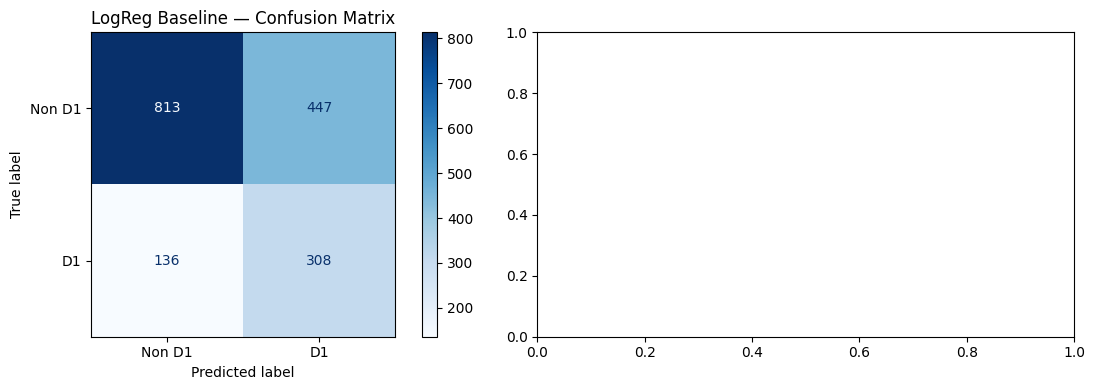

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

FEATURES = [
    "height", "weight",
    "exit_velo_max", "exit_velo_avg", "distance_max", "sweet_spot_p",
    "hand_speed_max", "bat_speed_max", "rot_acc_max", "hard_hit_p",
    "sixty_time", "thirty_time", "ten_yard_time", "run_speed_max",
    "of_velo",
]

X = of_model_recent[FEATURES]
y = of_model_recent["d1_or_not"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("impute", KNNImputer(n_neighbors=10)),
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Non D1", "D1"]))
print(confusion_matrix(y_test, y_pred), "\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Non D1", "D1"], ax=axes[0], cmap="Blues")
axes[0].set_title("LogReg Baseline — Confusion Matrix")

coefs = pd.Series(pipe["lr"].coef_[0], index=FEATURES).sort_values()
print(coefs)

plt.tight_layout()
plt.show()

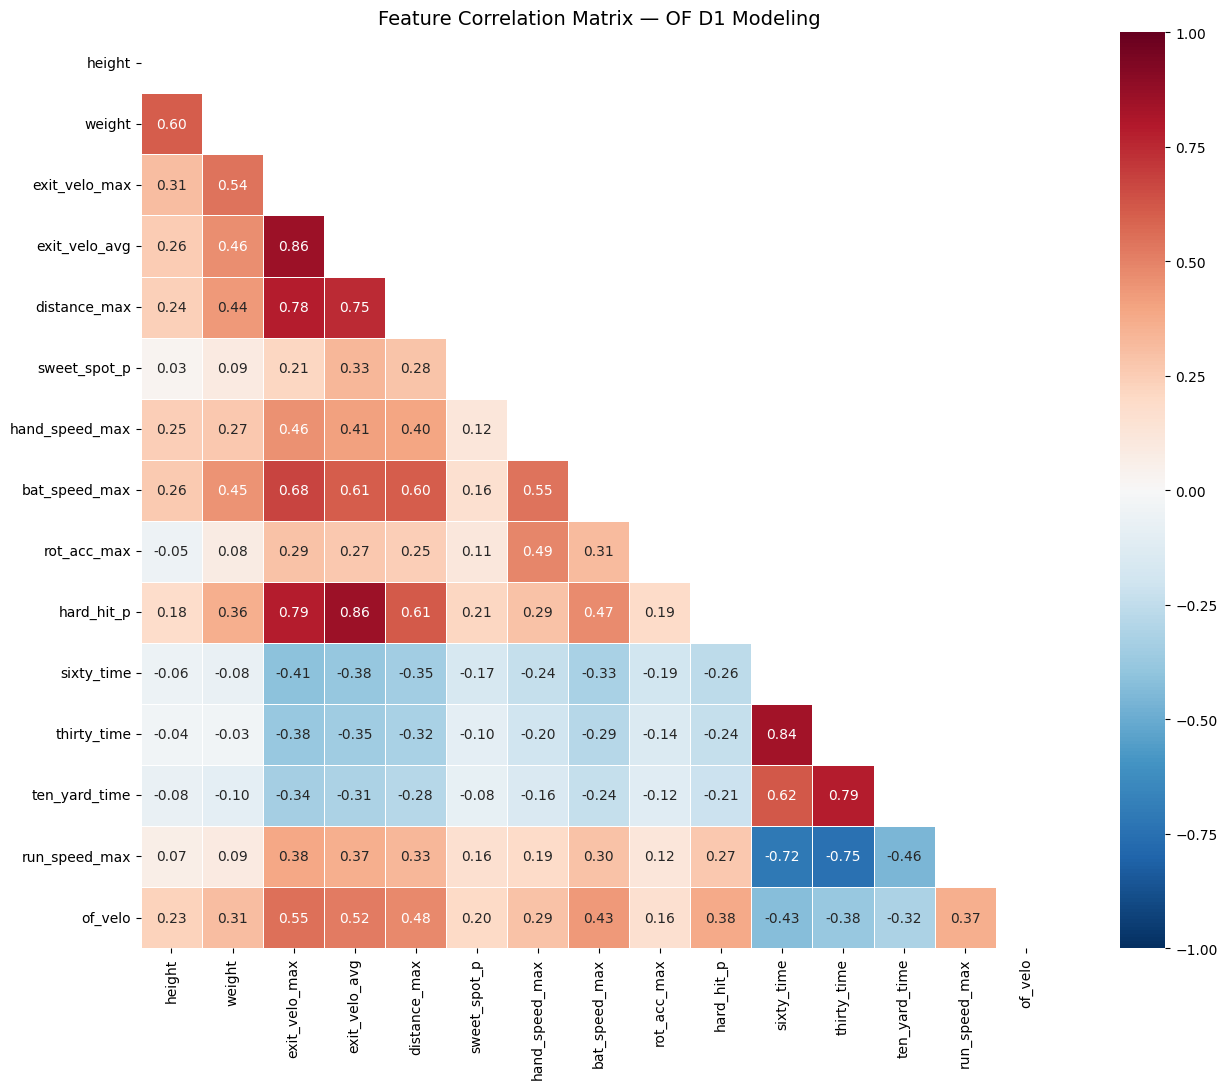


Highly correlated pairs (|r| > 0.7):
       exit_velo_max × exit_velo_avg       r = +0.859
       exit_velo_max × distance_max        r = +0.784
       exit_velo_max × hard_hit_p          r = +0.787
       exit_velo_avg × distance_max        r = +0.747
       exit_velo_avg × hard_hit_p          r = +0.858
          sixty_time × thirty_time         r = +0.838
          sixty_time × run_speed_max       r = -0.716
         thirty_time × ten_yard_time       r = +0.788
         thirty_time × run_speed_max       r = -0.749

                   height    weight  exit_velo_max  exit_velo_avg  distance_max  sweet_spot_p  hand_speed_max  bat_speed_max  rot_acc_max  hard_hit_p  sixty_time  thirty_time  ten_yard_time  run_speed_max   of_velo
height          1.000000  0.604027       0.312079       0.257418      0.241025      0.025548        0.246415       0.264521    -0.047476    0.183399   -0.062217    -0.038296      -0.076940       0.068073  0.227123
weight          0.604027  1.000000       0.540

In [102]:
import seaborn as sns

# Correlation matrix on the numeric features
corr = of_model_recent[FEATURES].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix — OF D1 Modeling", fontsize=14)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.7) — candidates for combining or dropping
print("\nHighly correlated pairs (|r| > 0.7):")
print("=" * 60)
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr.index[i]:>18} × {corr.columns[j]:<18}  r = {r:+.3f}")

print("\n", corr.to_string())

# What to look for:
# 1. exit_velo_max vs exit_velo_avg — likely r > 0.9, explains the sign flip in coefficients
# 2. sixty_time vs thirty_time vs ten_yard_time — all measuring speed, likely redundant
# 3. bat_speed_max vs hand_speed_max — related swing mechanics
# 4. exit_velo vs bat_speed — physical relationship (faster swing = harder contact)
# 5. distance_max vs exit_velo — distance is a function of EV + launch angle

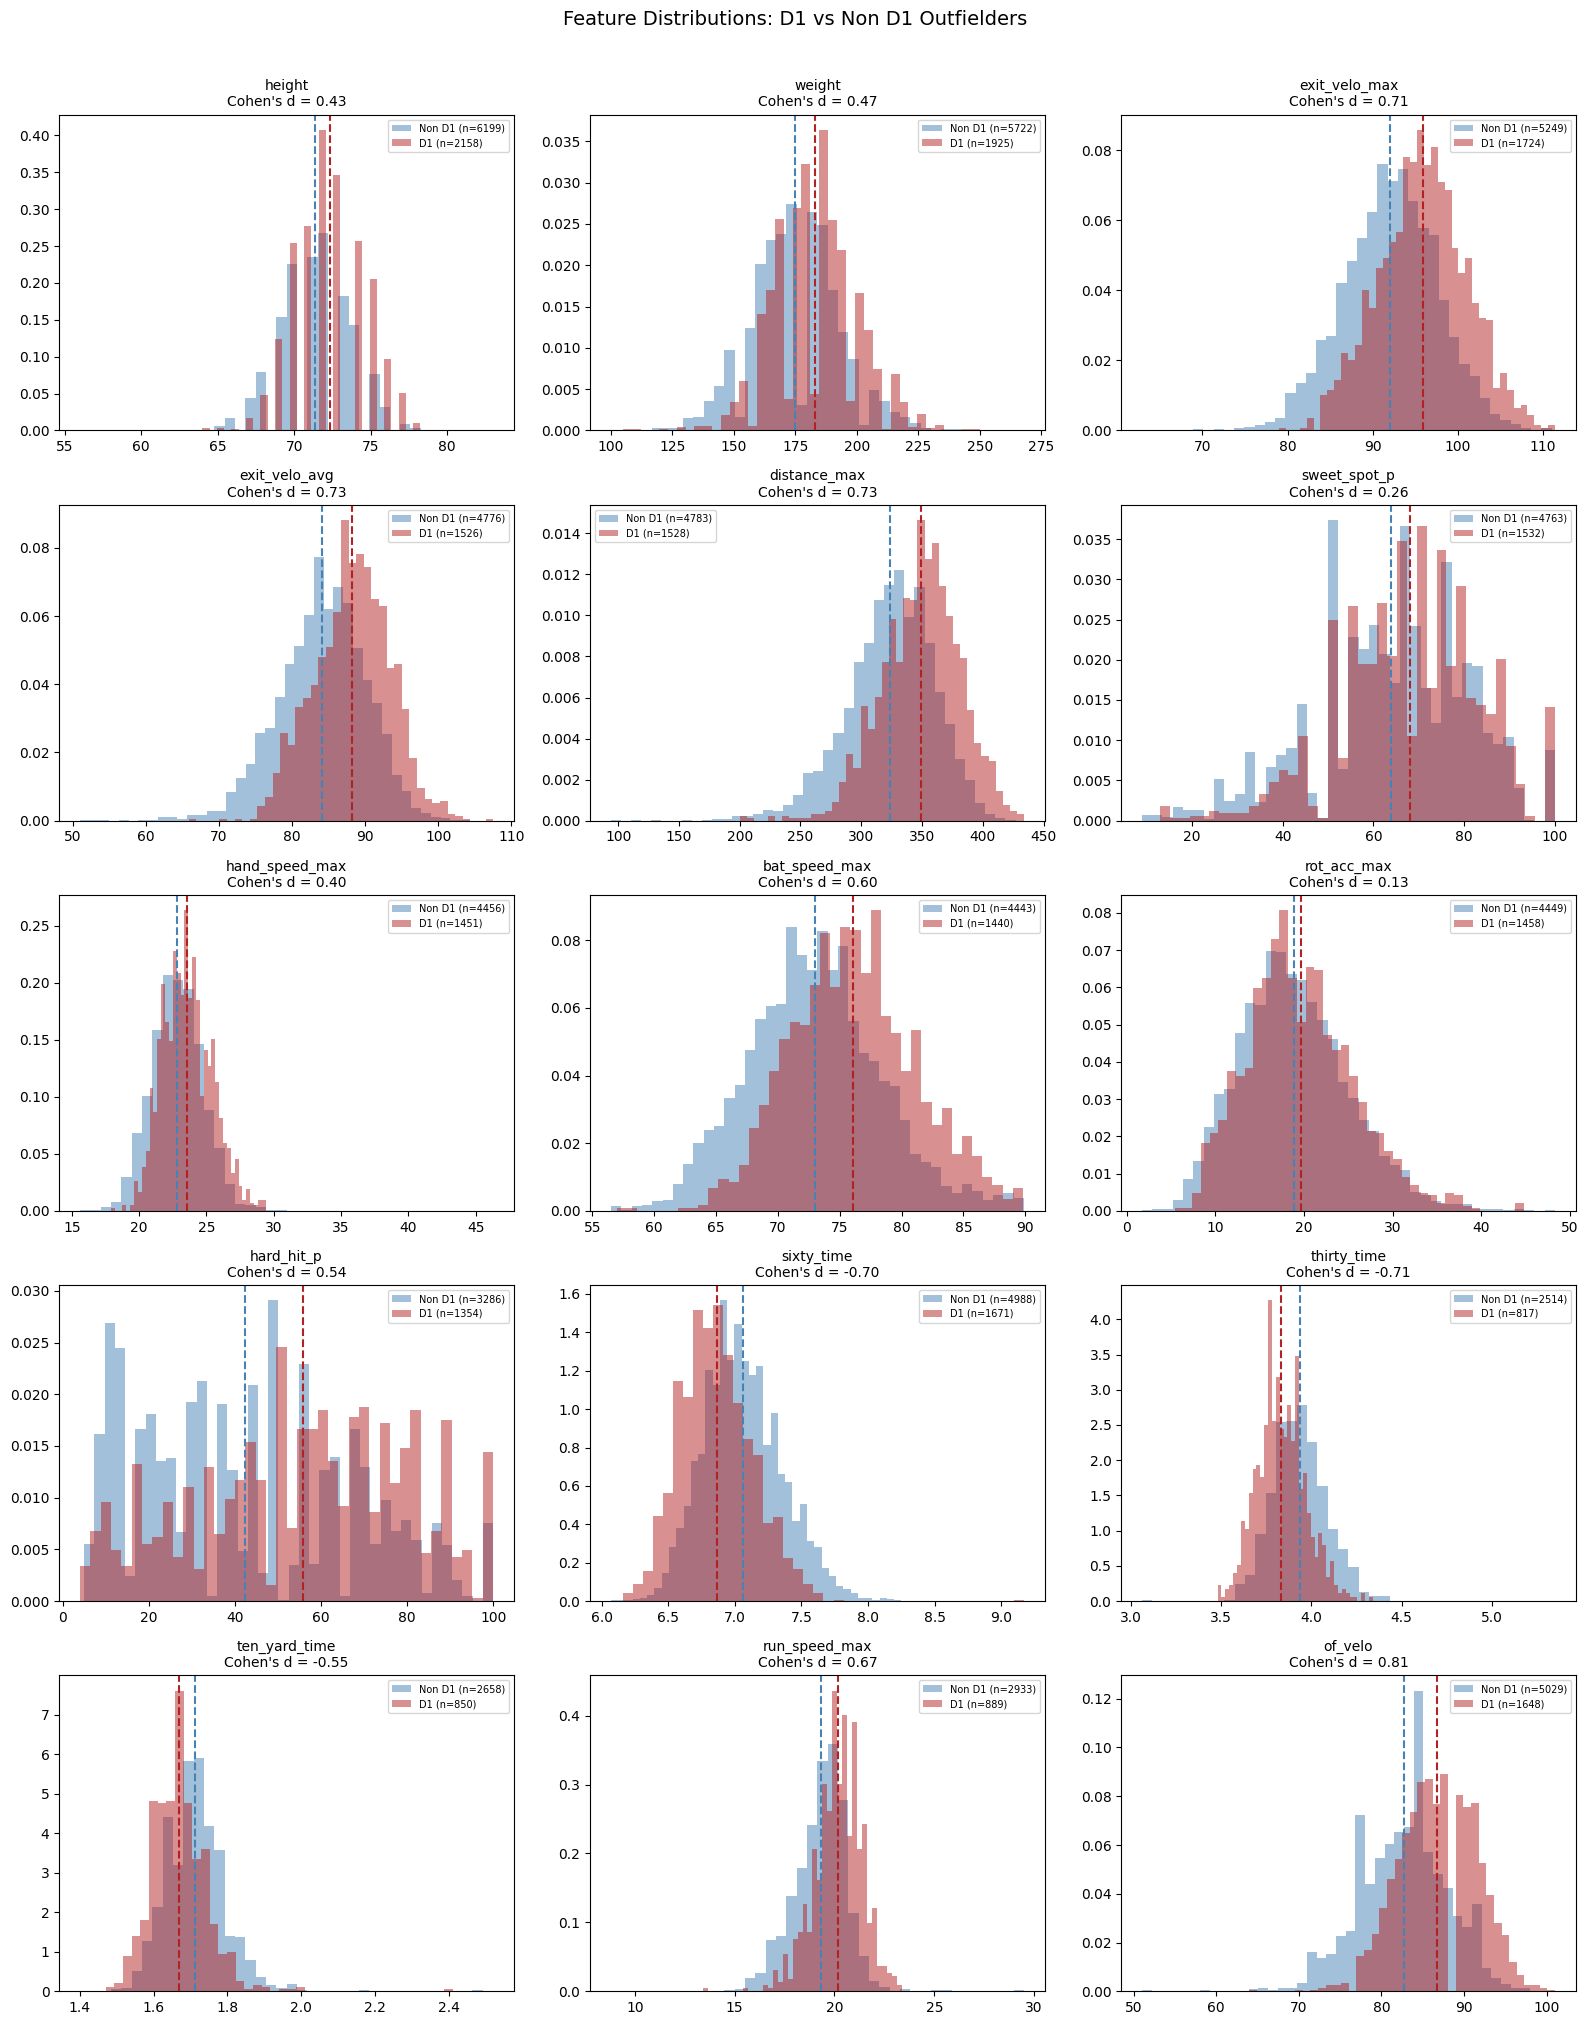


Effect sizes (Cohen's d) — sorted by separation power:
             of_velo  d = +0.809  ████████████████
       exit_velo_avg  d = +0.732  ██████████████
        distance_max  d = +0.731  ██████████████
       exit_velo_max  d = +0.713  ██████████████
         thirty_time  d = -0.707  ██████████████
          sixty_time  d = -0.699  █████████████
       run_speed_max  d = +0.666  █████████████
       bat_speed_max  d = +0.596  ███████████
       ten_yard_time  d = -0.548  ██████████
          hard_hit_p  d = +0.544  ██████████
              weight  d = +0.467  █████████
              height  d = +0.434  ████████
      hand_speed_max  d = +0.401  ████████
        sweet_spot_p  d = +0.264  █████
         rot_acc_max  d = +0.130  ██


In [103]:
'''
What you're looking for: Cohen's d tells you how much the D1 and Non D1 distributions actually separate. Features with |d| > 0.5 are strong separators. Features with |d| < 0.2 might be dead weight. 
Also look at the shape — if distributions are bimodal or heavily skewed, that suggests non-linear thresholds a tree model could exploit but logistic regression can't.
'''

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.ravel()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    d1_vals = of_model_recent.loc[of_model_recent["d1_or_not"] == 1, feat].dropna()
    non_d1_vals = of_model_recent.loc[of_model_recent["d1_or_not"] == 0, feat].dropna()

    ax.hist(non_d1_vals, bins=40, alpha=0.5, label=f"Non D1 (n={len(non_d1_vals)})", density=True, color="steelblue")
    ax.hist(d1_vals, bins=40, alpha=0.5, label=f"D1 (n={len(d1_vals)})", density=True, color="firebrick")

    # Show means
    ax.axvline(non_d1_vals.mean(), color="steelblue", linestyle="--", linewidth=1.5)
    ax.axvline(d1_vals.mean(), color="firebrick", linestyle="--", linewidth=1.5)

    # Effect size (Cohen's d)
    pooled_std = np.sqrt((non_d1_vals.std()**2 + d1_vals.std()**2) / 2)
    cohens_d = (d1_vals.mean() - non_d1_vals.mean()) / pooled_std if pooled_std > 0 else 0

    ax.set_title(f"{feat}\nCohen's d = {cohens_d:.2f}", fontsize=10)
    ax.legend(fontsize=7)

# Hide unused subplot if odd number of features
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions: D1 vs Non D1 Outfielders", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print("\nEffect sizes (Cohen's d) — sorted by separation power:")
print("=" * 55)
effects = []
for feat in FEATURES:
    d1 = of_model_recent.loc[of_model_recent["d1_or_not"] == 1, feat].dropna()
    nd1 = of_model_recent.loc[of_model_recent["d1_or_not"] == 0, feat].dropna()
    pooled = np.sqrt((nd1.std()**2 + d1.std()**2) / 2)
    d = (d1.mean() - nd1.mean()) / pooled if pooled > 0 else 0
    effects.append((feat, d))
for feat, d in sorted(effects, key=lambda x: abs(x[1]), reverse=True):
    bar = "█" * int(abs(d) * 20)
    print(f"  {feat:>18}  d = {d:+.3f}  {bar}")

Missing rate by class (D1 vs Non D1):
              height  D1: 2.7%   Non D1: 1.6%   gap: -1.1%  
              weight  D1: 13.2%   Non D1: 9.2%   gap: -4.0%  
       exit_velo_max  D1: 22.2%   Non D1: 16.7%   gap: -5.6%  
       exit_velo_avg  D1: 31.2%   Non D1: 24.2%   gap: -7.0%  
        distance_max  D1: 31.1%   Non D1: 24.1%   gap: -7.0%  
        sweet_spot_p  D1: 30.9%   Non D1: 24.4%   gap: -6.5%  
      hand_speed_max  D1: 34.6%   Non D1: 29.3%   gap: -5.3%  
       bat_speed_max  D1: 35.0%   Non D1: 29.5%   gap: -5.6%  
         rot_acc_max  D1: 34.2%   Non D1: 29.4%   gap: -4.9%  
          hard_hit_p  D1: 38.9%   Non D1: 47.8%   gap: +8.9%  ← D1 less missing
          sixty_time  D1: 24.6%   Non D1: 20.8%   gap: -3.8%  
         thirty_time  D1: 63.1%   Non D1: 60.1%   gap: -3.1%  
       ten_yard_time  D1: 61.7%   Non D1: 57.8%   gap: -3.9%  
       run_speed_max  D1: 59.9%   Non D1: 53.4%   gap: -6.5%  
             of_velo  D1: 25.7%   Non D1: 20.2%   gap: -5.5%  


M

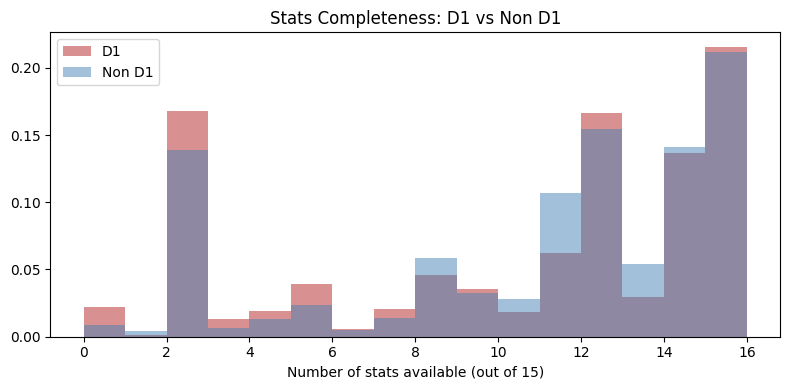

In [104]:
# Missingness can be informative: D1 players may have MORE stats recorded
# (more exposure, more showcases). This is a potential engineered feature.

miss_df = of_model_recent[FEATURES].isna()
miss_df["d1_or_not"] = of_model_recent["d1_or_not"]

print("Missing rate by class (D1 vs Non D1):")
print("=" * 65)
for feat in FEATURES:
    d1_miss = miss_df.loc[miss_df["d1_or_not"] == 1, feat].mean()
    nd1_miss = miss_df.loc[miss_df["d1_or_not"] == 0, feat].mean()
    diff = nd1_miss - d1_miss
    arrow = "← D1 less missing" if diff > 0.05 else ""
    print(f"  {feat:>18}  D1: {d1_miss:.1%}   Non D1: {nd1_miss:.1%}   gap: {diff:+.1%}  {arrow}")

# Engineered feature idea: count of non-null stats per player
of_model_recent["n_stats_available"] = of_model_recent[FEATURES].notna().sum(axis=1)

print(f"\n\nMean stats available per player:")
print(f"  D1:     {of_model_recent.loc[of_model_recent['d1_or_not']==1, 'n_stats_available'].mean():.1f}")
print(f"  Non D1: {of_model_recent.loc[of_model_recent['d1_or_not']==0, 'n_stats_available'].mean():.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(1, "firebrick"), (0, "steelblue")]:
    vals = of_model_recent.loc[of_model_recent["d1_or_not"] == label, "n_stats_available"]
    ax.hist(vals, bins=range(0, 17), alpha=0.5, label=f"{'D1' if label else 'Non D1'}", color=color, density=True)
ax.set_xlabel("Number of stats available (out of 15)")
ax.set_title("Stats Completeness: D1 vs Non D1")
ax.legend()
plt.tight_layout()
plt.show()

In [105]:
# Based on what we expect from the correlation matrix, test some engineered features
# These combine correlated features into single meaningful metrics

of_eng = of_model_recent.copy()

# 1. Power composite: combine the correlated EV/distance cluster
#    Standardize each, then average — captures "overall power" as one feature
power_feats = ["exit_velo_max", "exit_velo_avg", "distance_max"]
scaler = StandardScaler()
power_scaled = pd.DataFrame(
    scaler.fit_transform(of_eng[power_feats].fillna(of_eng[power_feats].median())),
    index=of_eng.index, columns=power_feats
)
of_eng["power_composite"] = power_scaled.mean(axis=1)

# 2. Speed composite: combine correlated speed metrics
speed_feats = ["sixty_time", "thirty_time", "ten_yard_time"]  # lower = faster, so negate
speed_scaled = pd.DataFrame(
    scaler.fit_transform(of_eng[speed_feats].fillna(of_eng[speed_feats].median())),
    index=of_eng.index, columns=speed_feats
)
of_eng["speed_composite"] = -speed_scaled.mean(axis=1)  # negate so higher = faster

# 3. Bat control ratio: sweet spot % relative to bat speed
#    Higher sweet_spot at same bat_speed = better bat control
of_eng["bat_control"] = of_eng["sweet_spot_p"] / of_eng["bat_speed_max"].replace(0, np.nan)

# 4. Power-to-weight: exit velo normalized by weight (efficiency)
of_eng["ev_per_lb"] = of_eng["exit_velo_max"] / of_eng["weight"].replace(0, np.nan)

# 5. Stats completeness (from above)
of_eng["n_stats_available"] = of_model_recent[FEATURES].notna().sum(axis=1)

# Quick check: how well do these new features separate D1 vs Non D1?
new_feats = ["power_composite", "speed_composite", "bat_control", "ev_per_lb", "n_stats_available"]
print("Engineered Feature Effect Sizes:")
print("=" * 50)
for feat in new_feats:
    d1 = of_eng.loc[of_eng["d1_or_not"] == 1, feat].dropna()
    nd1 = of_eng.loc[of_eng["d1_or_not"] == 0, feat].dropna()
    pooled = np.sqrt((nd1.std()**2 + d1.std()**2) / 2)
    d = (d1.mean() - nd1.mean()) / pooled if pooled > 0 else 0
    bar = "█" * int(abs(d) * 20)
    print(f"  {feat:>20}  d = {d:+.3f}  {bar}")

print("\n\nCompare with raw features for context:")
for feat in ["of_velo", "sixty_time", "exit_velo_max", "height"]:
    d1 = of_eng.loc[of_eng["d1_or_not"] == 1, feat].dropna()
    nd1 = of_eng.loc[of_eng["d1_or_not"] == 0, feat].dropna()
    pooled = np.sqrt((nd1.std()**2 + d1.std()**2) / 2)
    d = (d1.mean() - nd1.mean()) / pooled if pooled > 0 else 0
    bar = "█" * int(abs(d) * 20)
    print(f"  {feat:>20}  d = {d:+.3f}  {bar}")

Engineered Feature Effect Sizes:
       power_composite  d = +0.666  █████████████
       speed_composite  d = +0.533  ██████████
           bat_control  d = +0.080  █
             ev_per_lb  d = -0.087  █
     n_stats_available  d = -0.128  ██


Compare with raw features for context:
               of_velo  d = +0.809  ████████████████
            sixty_time  d = -0.699  █████████████
         exit_velo_max  d = +0.713  ██████████████
                height  d = +0.434  ████████


## XGBoost — Core Features + bat_speed_max

Using the 7 production-realistic features:
- **Core 6:** height, weight, exit_velo_max, distance_max, sixty_time, of_velo
- **Optional:** bat_speed_max

XGBoost handles missing values natively (no imputation needed) and doesn't suffer from multicollinearity like logistic regression.

In [107]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ============================================================
# XGBoost — 7 production features
# ============================================================
FEATURES_XGB = [
    "height", "weight",
    "exit_velo_max", "distance_max",
    "sixty_time",
    "of_velo",
    "bat_speed_max",
]

X = of_model_recent[FEATURES_XGB]
y = of_model_recent["d1_or_not"]

# Class imbalance ratio for scale_pos_weight
neg, pos = (y == 0).sum(), (y == 1).sum()
print(f"Class balance: {neg} Non D1, {pos} D1  (ratio {neg/pos:.2f}:1)\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=3.0,
    min_child_weight=5,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42,
    enable_categorical=False,
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

# --- Classification report ---
print("XGBoost — 7 Features (holdout)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Non D1", "D1"]))
print(confusion_matrix(y_test, y_pred), "\n")

# --- AUC-ROC (primary metric — measures ordering quality) ---
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}  (1.0 = perfect ordering, 0.5 = random)")
print(f"  -> {auc:.0%} of the time, a random D1 player scores higher than a random Non-D1 player\n")

# --- Feature importance (sorted by importance, highest first) ---
importances = pd.Series(xgb.feature_importances_, index=FEATURES_XGB).sort_values(ascending=False)
print(importances)

# --- Stratified K-Fold cross-validation (train + test) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    xgb, X, y, cv=skf,
    scoring=["roc_auc", "f1", "precision", "recall", "accuracy"],
    return_train_score=True,
)

print(f"\n\nStratified 5-Fold CV:")
print("=" * 55)
for metric in ["roc_auc", "accuracy", "f1", "precision", "recall"]:
    train_scores = cv_results[f"train_{metric}"]
    test_scores = cv_results[f"test_{metric}"]
    label = "AUC-ROC" if metric == "roc_auc" else metric
    print(f"  {label:>12}:  train {train_scores.mean():.3f} (+/- {train_scores.std():.3f})  |  test {test_scores.mean():.3f} (+/- {test_scores.std():.3f})")

print(f"\n  Overfit check (train - test AUC): {cv_results['train_roc_auc'].mean() - cv_results['test_roc_auc'].mean():.3f}")

# --- Compare with LogReg baseline ---
print(f"\n{'=' * 55}")
print("COMPARISON: LogReg (15 feat) vs XGBoost (7 feat)")
print(f"{'=' * 55}")
xgb_report = classification_report(y_test, y_pred, target_names=["Non D1", "D1"], output_dict=True)
print(f"  LogReg baseline:  D1 precision=0.41  D1 recall=0.69  D1 F1=0.51  accuracy=0.66")
print(f"  XGBoost 7-feat:   D1 precision={xgb_report['D1']['precision']:.2f}  "
      f"D1 recall={xgb_report['D1']['recall']:.2f}  "
      f"D1 F1={xgb_report['D1']['f1-score']:.2f}  "
      f"accuracy={xgb_report['accuracy']:.2f}  "
      f"AUC={auc:.3f}")

Class balance: 6299 Non D1, 2217 D1  (ratio 2.84:1)

XGBoost — 7 Features (holdout)
              precision    recall  f1-score   support

      Non D1       0.87      0.68      0.76      1260
          D1       0.44      0.72      0.55       444

    accuracy                           0.69      1704
   macro avg       0.66      0.70      0.65      1704
weighted avg       0.76      0.69      0.71      1704

[[852 408]
 [123 321]] 

AUC-ROC: 0.7697  (1.0 = perfect ordering, 0.5 = random)
  -> 77% of the time, a random D1 player scores higher than a random Non-D1 player

of_velo          0.283392
sixty_time       0.163170
weight           0.135482
distance_max     0.132373
height           0.115028
exit_velo_max    0.091275
bat_speed_max    0.079280
dtype: float32


Stratified 5-Fold CV:
       AUC-ROC:  train 0.824 (+/- 0.004)  |  test 0.760 (+/- 0.012)
      accuracy:  train 0.721 (+/- 0.006)  |  test 0.681 (+/- 0.011)
            f1:  train 0.594 (+/- 0.004)  |  test 0.536 (+/- 0.013)

In [108]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_proba = xgb.predict_proba(X_test)[:, 1]
fraction_pos, mean_predicted = calibration_curve(y_test, y_proba, n_bins=10)

print("Probability Calibration (predicted D1 prob vs actual D1 rate):")
print("=" * 60)
print(f"  {'Predicted':>12}  {'Actual':>8}  {'Gap':>8}")
print(f"  {'-'*12}  {'-'*8}  {'-'*8}")
for pred, actual in zip(mean_predicted, fraction_pos):
    gap = pred - actual
    flag = "  <- overconfident" if gap > 0.10 else ("  <- underconfident" if gap < -0.10 else "")
    print(f"  {pred:>12.2f}  {actual:>8.2f}  {gap:>+8.2f}{flag}")

brier = brier_score_loss(y_test, y_proba)
print(f"\nBrier score: {brier:.4f}  (lower = better, <0.20 is decent)")

# How this impacts PCI
print(f"\n\nPCI impact of calibration errors:")
print("=" * 60)
print("  Non-D1 band:    (d1_prob - 0.15) * 25.0  ->  +/- 25 pt swing")
print("  Non-P4 D1 band: (d1_prob - 0.65) * 6.0   ->  +/- 6 pt swing")
print(f"\n  If model says 0.40 but true rate is 0.30:")
print(f"    Non-D1 PCI error = (0.40 - 0.30) * 25 = 2.5 points")
print(f"    That's half a fit category (delta thresholds are 4 pts apart)")

Probability Calibration (predicted D1 prob vs actual D1 rate):
     Predicted    Actual       Gap
  ------------  --------  --------
          0.04      0.03     +0.02
          0.15      0.05     +0.10  <- overconfident
          0.26      0.16     +0.10  <- overconfident
          0.35      0.14     +0.21  <- overconfident
          0.45      0.20     +0.25  <- overconfident
          0.55      0.30     +0.25  <- overconfident
          0.65      0.38     +0.27  <- overconfident
          0.75      0.54     +0.21  <- overconfident
          0.85      0.68     +0.16  <- overconfident
          0.92      0.73     +0.19  <- overconfident

Brier score: 0.1975  (lower = better, <0.20 is decent)


PCI impact of calibration errors:
  Non-D1 band:    (d1_prob - 0.15) * 25.0  ->  +/- 25 pt swing
  Non-P4 D1 band: (d1_prob - 0.65) * 6.0   ->  +/- 6 pt swing

  If model says 0.40 but true rate is 0.30:
    Non-D1 PCI error = (0.40 - 0.30) * 25 = 2.5 points
    That's half a fit category (delta 

## Calibrated XGBoost

The raw XGBoost probabilities are systematically overconfident (predicts 0.45 when true rate is 0.20). Isotonic regression learns a post-hoc mapping from raw probabilities to actual observed rates, fixing this without changing the model's classification ability.

In [109]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, classification_report, confusion_matrix

# ============================================================
# Calibrated XGBoost — isotonic regression on top of raw model
# ============================================================
# cv=5 means it does 5-fold internal CV to learn the calibration mapping
# without leaking test data
xgb_calibrated = CalibratedClassifierCV(xgb, method="isotonic", cv=5)
xgb_calibrated.fit(X_train, y_train)

y_pred_cal = xgb_calibrated.predict(X_test)
y_proba_cal = xgb_calibrated.predict_proba(X_test)[:, 1]

# --- Classification report (should be similar to raw XGBoost) ---
print("Calibrated XGBoost — 7 Features (holdout)")
print("=" * 60)
print(classification_report(y_test, y_pred_cal, target_names=["Non D1", "D1"]))
print(confusion_matrix(y_test, y_pred_cal), "\n")

# --- Calibration check: before vs after ---
fraction_raw, mean_raw = calibration_curve(y_test, y_proba, n_bins=10)
fraction_cal, mean_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

print("Calibration comparison (raw vs calibrated):")
print("=" * 75)
print(f"  {'--- RAW ---':^28}   |   {'--- CALIBRATED ---':^28}")
print(f"  {'Predicted':>10}  {'Actual':>8}  {'Gap':>8}   |   {'Predicted':>10}  {'Actual':>8}  {'Gap':>8}")
print(f"  {'-'*28}   |   {'-'*28}")

max_rows = max(len(mean_raw), len(mean_cal))
for i in range(max_rows):
    if i < len(mean_raw):
        r_gap = mean_raw[i] - fraction_raw[i]
        raw_str = f"  {mean_raw[i]:>10.2f}  {fraction_raw[i]:>8.2f}  {r_gap:>+8.2f}"
    else:
        raw_str = f"  {'':>28}"
    if i < len(mean_cal):
        c_gap = mean_cal[i] - fraction_cal[i]
        cal_str = f"{mean_cal[i]:>10.2f}  {fraction_cal[i]:>8.2f}  {c_gap:>+8.2f}"
    else:
        cal_str = f"{'':>28}"
    print(f"{raw_str}   |   {cal_str}")

# --- Brier score comparison ---
brier_raw = brier_score_loss(y_test, y_proba)
brier_cal = brier_score_loss(y_test, y_proba_cal)
print(f"\nBrier score:  raw = {brier_raw:.4f}  |  calibrated = {brier_cal:.4f}  |  improvement = {brier_raw - brier_cal:.4f}")

# --- PCI impact ---
max_gap_raw = max(abs(mean_raw[i] - fraction_raw[i]) for i in range(len(mean_raw)))
max_gap_cal = max(abs(mean_cal[i] - fraction_cal[i]) for i in range(len(mean_cal)))
print(f"Max calibration gap:  raw = {max_gap_raw:.2f}  |  calibrated = {max_gap_cal:.2f}")
print(f"Worst-case Non-D1 PCI error:  raw = {max_gap_raw * 25:.1f} pts  |  calibrated = {max_gap_cal * 25:.1f} pts")

Calibrated XGBoost — 7 Features (holdout)
              precision    recall  f1-score   support

      Non D1       0.79      0.95      0.86      1260
          D1       0.67      0.28      0.39       444

    accuracy                           0.78      1704
   macro avg       0.73      0.61      0.63      1704
weighted avg       0.76      0.78      0.74      1704

[[1199   61]
 [ 321  123]] 

Calibration comparison (raw vs calibrated):
          --- RAW ---            |        --- CALIBRATED ---     
   Predicted    Actual       Gap   |    Predicted    Actual       Gap
  ----------------------------   |   ----------------------------
        0.04      0.03     +0.02   |         0.04      0.05     -0.01
        0.15      0.05     +0.10   |         0.15      0.16     -0.01
        0.26      0.16     +0.10   |         0.25      0.19     +0.05
        0.35      0.14     +0.21   |         0.34      0.33     +0.02
        0.45      0.20     +0.25   |         0.45      0.44     +0.01
      

## Feature Engineering

Build `of_eng` from the core 7 production features + interaction terms that capture multi-tool athleticism XGBoost can't easily learn in a single split.

In [110]:
CORE_7 = ["height", "weight", "exit_velo_max", "distance_max", "sixty_time", "of_velo", "bat_speed_max"]

of_eng = of_model_recent[CORE_7 + ["d1_or_not"]].copy()

# --- Interaction features ---
# Defensive tools: high arm velo + fast 60 = elite OF defender
# sixty is lower=better, so dividing makes high values = good
of_eng["arm_speed_ratio"] = of_eng["of_velo"] / of_eng["sixty_time"]

# Raw two-way tools: arm strength × bat power
of_eng["velo_x_exit"] = of_eng["of_velo"] * of_eng["exit_velo_max"]

# Power tools: bat speed × exit velo = swing-to-contact transfer
of_eng["bat_x_exit"] = of_eng["bat_speed_max"] * of_eng["exit_velo_max"]

# Distance × arm velo: overall power + arm combo
of_eng["dist_x_arm"] = of_eng["distance_max"] * of_eng["of_velo"]

# Body mass index proxy (height in inches, weight in lbs)
of_eng["bmi_proxy"] = of_eng["weight"] / (of_eng["height"] ** 2) * 703

# Speed-adjusted power: high exit velo relative to how fast you run
# fast + powerful = elite athlete
of_eng["exit_per_sixty"] = of_eng["exit_velo_max"] / of_eng["sixty_time"]

# --- Check separation ---
ENG_FEATURES = [c for c in of_eng.columns if c not in ["d1_or_not"]]

print(f"of_eng: {of_eng.shape[0]} rows, {len(ENG_FEATURES)} features")
print(f"  Core: {len(CORE_7)}  |  Engineered: {len(ENG_FEATURES) - len(CORE_7)}\n")

print("Cohen's d (sorted by |d|):")
print("=" * 55)
effects = []
for feat in ENG_FEATURES:
    d1 = of_eng.loc[of_eng["d1_or_not"] == 1, feat].dropna()
    nd1 = of_eng.loc[of_eng["d1_or_not"] == 0, feat].dropna()
    pooled = np.sqrt((nd1.std()**2 + d1.std()**2) / 2)
    d = (d1.mean() - nd1.mean()) / pooled if pooled > 0 else 0
    effects.append((feat, d))
for feat, d in sorted(effects, key=lambda x: abs(x[1]), reverse=True):
    tag = " *" if feat not in CORE_7 else ""
    print(f"  {feat:>20}  d = {d:+.3f}{tag}")

print("\n* = engineered feature")

# Correlation between engineered features and their parents
print("\nEngineered feature correlations with parents:")
print("=" * 55)
eng_pairs = [
    ("arm_speed_ratio", ["of_velo", "sixty_time"]),
    ("velo_x_exit",     ["of_velo", "exit_velo_max"]),
    ("bat_x_exit",      ["bat_speed_max", "exit_velo_max"]),
    ("dist_x_arm",      ["distance_max", "of_velo"]),
    ("exit_per_sixty",  ["exit_velo_max", "sixty_time"]),
    ("bmi_proxy",       ["height", "weight"]),
]
for eng, parents in eng_pairs:
    corrs = [of_eng[eng].corr(of_eng[p]) for p in parents]
    corr_str = ", ".join(f"{p}={c:.2f}" for p, c in zip(parents, corrs))
    print(f"  {eng:>20} -> {corr_str}")

of_eng: 8516 rows, 13 features
  Core: 7  |  Engineered: 6

Cohen's d (sorted by |d|):
       arm_speed_ratio  d = +0.925 *
           velo_x_exit  d = +0.901 *
            dist_x_arm  d = +0.900 *
        exit_per_sixty  d = +0.874 *
               of_velo  d = +0.809
          distance_max  d = +0.731
            bat_x_exit  d = +0.730 *
         exit_velo_max  d = +0.713
            sixty_time  d = -0.699
         bat_speed_max  d = +0.596
                weight  d = +0.467
                height  d = +0.434
             bmi_proxy  d = +0.249 *

* = engineered feature

Engineered feature correlations with parents:
       arm_speed_ratio -> of_velo=0.91, sixty_time=-0.77
           velo_x_exit -> of_velo=0.89, exit_velo_max=0.87
            bat_x_exit -> bat_speed_max=0.94, exit_velo_max=0.89
            dist_x_arm -> distance_max=0.93, of_velo=0.77
        exit_per_sixty -> exit_velo_max=0.89, sixty_time=-0.77
             bmi_proxy -> height=-0.04, weight=0.77


XGBoost with engineered features

In [111]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# ============================================================
# XGBoost — Engineered Features
# ============================================================
FEATURES_ENG = [c for c in of_eng.columns if c != "d1_or_not"]

X = of_eng[FEATURES_ENG]
y = of_eng["d1_or_not"]
neg, pos = (y == 0).sum(), (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_eng = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=3.0,
    min_child_weight=5,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42,
    enable_categorical=False,
)

xgb_eng.fit(X_train, y_train)
y_pred = xgb_eng.predict(X_test)
y_proba = xgb_eng.predict_proba(X_test)[:, 1]

# --- Classification report ---
print(f"XGBoost — {len(FEATURES_ENG)} Features (7 core + {len(FEATURES_ENG)-7} engineered)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Non D1", "D1"]))
print(confusion_matrix(y_test, y_pred))

# --- AUC-ROC ---
auc_eng = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc_eng:.4f}")

# --- Feature importance ---
importances = pd.Series(xgb_eng.feature_importances_, index=FEATURES_ENG).sort_values(ascending=False)
print(f"\nFeature importance:")
print(importances.to_string())

# --- Stratified 5-Fold CV ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_validate(
    xgb_eng, X, y, cv=skf,
    scoring=["roc_auc", "f1", "precision", "recall", "accuracy"],
    return_train_score=True,
)

print(f"\nStratified 5-Fold CV:")
print("=" * 60)
for metric in ["roc_auc", "accuracy", "f1", "precision", "recall"]:
    tr = cv[f"train_{metric}"]
    te = cv[f"test_{metric}"]
    label = "AUC-ROC" if metric == "roc_auc" else metric
    print(f"  {label:>12}:  train {tr.mean():.3f} (+/- {tr.std():.3f})  |  test {te.mean():.3f} (+/- {te.std():.3f})")
print(f"\n  Overfit gap (AUC): {cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean():.3f}")

# --- Calibration ---
xgb_eng_cal = CalibratedClassifierCV(xgb_eng, method="isotonic", cv=5)
xgb_eng_cal.fit(X_train, y_train)
y_pred_cal = xgb_eng_cal.predict(X_test)
y_proba_cal = xgb_eng_cal.predict_proba(X_test)[:, 1]

fraction_cal, mean_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)
brier_raw = brier_score_loss(y_test, y_proba)
brier_cal = brier_score_loss(y_test, y_proba_cal)

print(f"\nCalibrated model:")
print("=" * 60)
print(classification_report(y_test, y_pred_cal, target_names=["Non D1", "D1"]))
print(f"Brier:  raw = {brier_raw:.4f}  |  calibrated = {brier_cal:.4f}")
print(f"\nCalibration curve (calibrated):")
print(f"  {'Predicted':>10}  {'Actual':>8}  {'Gap':>8}")
for pred, actual in zip(mean_cal, fraction_cal):
    gap = pred - actual
    flag = "  <- off" if abs(gap) > 0.10 else ""
    print(f"  {pred:>10.2f}  {actual:>8.2f}  {gap:>+8.2f}{flag}")

# --- Comparison vs base 7-feature model ---
print(f"\n{'=' * 60}")
print(f"COMPARISON: 7-feature vs {len(FEATURES_ENG)}-feature engineered")
print(f"{'=' * 60}")
eng_report = classification_report(y_test, y_pred, target_names=["Non D1", "D1"], output_dict=True)
print(f"  7-feat base:    AUC=0.7697  Brier(cal)=0.1577  D1 F1=0.55")
print(f"  {len(FEATURES_ENG)}-feat eng:     AUC={auc_eng:.4f}  Brier(cal)={brier_cal:.4f}  D1 F1={eng_report['D1']['f1-score']:.2f}")

XGBoost — 13 Features (7 core + 6 engineered)
              precision    recall  f1-score   support

      Non D1       0.87      0.66      0.75      1260
          D1       0.43      0.73      0.54       444

    accuracy                           0.68      1704
   macro avg       0.65      0.69      0.65      1704
weighted avg       0.76      0.68      0.70      1704

[[830 430]
 [120 324]]

AUC-ROC: 0.7729

Feature importance:
velo_x_exit        0.173316
dist_x_arm         0.129791
arm_speed_ratio    0.113023
exit_per_sixty     0.095212
weight             0.075106
height             0.074290
sixty_time         0.071117
of_velo            0.059015
distance_max       0.048216
bat_x_exit         0.045795
bat_speed_max      0.042127
bmi_proxy          0.036959
exit_velo_max      0.036033

Stratified 5-Fold CV:
       AUC-ROC:  train 0.834 (+/- 0.002)  |  test 0.760 (+/- 0.014)
      accuracy:  train 0.727 (+/- 0.004)  |  test 0.683 (+/- 0.011)
            f1:  train 0.603 (+/- 0.004)  |

## XGBoost — 7 Core + Region (One-Hot)

Test whether `player_region` adds geographic signal on top of the physical measurables.

In [112]:
CORE_7 = ["height", "weight", "exit_velo_max", "distance_max", "sixty_time", "of_velo", "bat_speed_max"]

of_region = of_model_recent[CORE_7 + ["player_region", "d1_or_not"]].copy()

print("Region distribution:")
print(of_region["player_region"].value_counts())
print(f"\nD1 rate by region:")
for region in sorted(of_region["player_region"].dropna().unique()):
    mask = of_region["player_region"] == region
    rate = of_region.loc[mask, "d1_or_not"].mean()
    n = mask.sum()
    print(f"  {region:>12}: {rate:.1%} D1  (n={n})")

region_dummies = pd.get_dummies(of_region["player_region"], prefix="region", drop_first=True, dtype=int)
of_region = pd.concat([of_region.drop(columns=["player_region"]), region_dummies], axis=1)

FEATURES_REG = [c for c in of_region.columns if c != "d1_or_not"]
X = of_region[FEATURES_REG]
y = of_region["d1_or_not"]
neg, pos = (y == 0).sum(), (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_reg = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=3.0, min_child_weight=5,
    scale_pos_weight=neg / pos, eval_metric="logloss",
    random_state=42, enable_categorical=False,
)

xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_test)
y_proba = xgb_reg.predict_proba(X_test)[:, 1]

print(f"\nXGBoost — 7 Core + Region ({len(FEATURES_REG)} total features)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Non D1", "D1"]))
print(confusion_matrix(y_test, y_pred))

auc_reg = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc_reg:.4f}")

importances = pd.Series(xgb_reg.feature_importances_, index=FEATURES_REG).sort_values(ascending=False)
print(f"\nFeature importance:")
print(importances.to_string())

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_validate(
    xgb_reg, X, y, cv=skf,
    scoring=["roc_auc", "f1", "precision", "recall", "accuracy"],
    return_train_score=True,
)

print(f"\nStratified 5-Fold CV:")
print("=" * 60)
for metric in ["roc_auc", "accuracy", "f1", "precision", "recall"]:
    tr = cv[f"train_{metric}"]
    te = cv[f"test_{metric}"]
    label = "AUC-ROC" if metric == "roc_auc" else metric
    print(f"  {label:>12}:  train {tr.mean():.3f} (+/- {tr.std():.3f})  |  test {te.mean():.3f} (+/- {te.std():.3f})")
print(f"\n  Overfit gap (AUC): {cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean():.3f}")

xgb_reg_cal = CalibratedClassifierCV(xgb_reg, method="isotonic", cv=5)
xgb_reg_cal.fit(X_train, y_train)
y_pred_cal = xgb_reg_cal.predict(X_test)
y_proba_cal = xgb_reg_cal.predict_proba(X_test)[:, 1]

fraction_cal, mean_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)
brier_raw = brier_score_loss(y_test, y_proba)
brier_cal = brier_score_loss(y_test, y_proba_cal)

print(f"\nCalibrated model:")
print("=" * 60)
print(classification_report(y_test, y_pred_cal, target_names=["Non D1", "D1"]))
print(f"Brier:  raw = {brier_raw:.4f}  |  calibrated = {brier_cal:.4f}")
print(f"\nCalibration curve (calibrated):")
print(f"  {'Predicted':>10}  {'Actual':>8}  {'Gap':>8}")
for pred, actual in zip(mean_cal, fraction_cal):
    gap = pred - actual
    flag = "  <- off" if abs(gap) > 0.10 else ""
    print(f"  {pred:>10.2f}  {actual:>8.2f}  {gap:>+8.2f}{flag}")

print(f"\n{'=' * 60}")
print("COMPARISON: 7-feat base vs 7-feat + region")
print(f"{'=' * 60}")
print(f"  7-feat base:       AUC=0.7697  CV AUC=0.760  Brier(cal)=0.1577  overfit=0.065")
print(f"  7-feat + region:   AUC={auc_reg:.4f}  CV AUC={cv['test_roc_auc'].mean():.3f}  Brier(cal)={brier_cal:.4f}  overfit={cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean():.3f}")

Region distribution:
player_region
South        2994
Midwest      2648
Northeast    1445
West         1143
Name: count, dtype: int64

D1 rate by region:
       Midwest: 14.3% D1  (n=2648)
     Northeast: 25.8% D1  (n=1445)
         South: 34.0% D1  (n=2994)
          West: 35.8% D1  (n=1143)

XGBoost — 7 Core + Region (10 total features)
              precision    recall  f1-score   support

      Non D1       0.88      0.70      0.78      1260
          D1       0.47      0.73      0.57       444

    accuracy                           0.71      1704
   macro avg       0.67      0.72      0.68      1704
weighted avg       0.77      0.71      0.73      1704

[[888 372]
 [119 325]]

AUC-ROC: 0.8074

Feature importance:
of_velo             0.187948
region_South        0.141685
region_West         0.133416
sixty_time          0.102124
region_Northeast    0.091652
distance_max        0.087831
weight              0.076264
height              0.073129
exit_velo_max       0.055978
bat_speed_m

Not adding region as it is discriminatory and not in the users interests since it is correlated with outside factors like opportunity, etc.

In [115]:
# ============================================================
# XGBoost — 7 production features
# ============================================================
FEATURES_XGB = [
    "height", "weight",
    "exit_velo_max", "distance_max",
    "sixty_time",
    "of_velo",
    "bat_speed_max",
]

X = of_model_recent[FEATURES_XGB]
y = of_model_recent["d1_or_not"]

# Class imbalance ratio for scale_pos_weight
neg, pos = (y == 0).sum(), (y == 1).sum()
print(f"Class balance: {neg} Non D1, {pos} D1  (ratio {neg/pos:.2f}:1)\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=3.0,
    min_child_weight=5,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42,
    enable_categorical=False,
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

# --- Classification report ---
print("XGBoost — 7 Features (holdout)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Non D1", "D1"]))
print(confusion_matrix(y_test, y_pred), "\n")

# --- AUC-ROC (primary metric — measures ordering quality) ---
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}  (1.0 = perfect ordering, 0.5 = random)")
print(f"  -> {auc:.0%} of the time, a random D1 player scores higher than a random Non-D1 player\n")

# --- Feature importance (sorted by importance, highest first) ---
importances = pd.Series(xgb.feature_importances_, index=FEATURES_XGB).sort_values(ascending=False)
print(importances)

# --- Stratified K-Fold cross-validation (train + test) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    xgb, X, y, cv=skf,
    scoring=["roc_auc", "f1", "precision", "recall", "accuracy"],
    return_train_score=True,
)

print(f"\n\nStratified 5-Fold CV:")
print("=" * 55)
for metric in ["roc_auc", "accuracy", "f1", "precision", "recall"]:
    train_scores = cv_results[f"train_{metric}"]
    test_scores = cv_results[f"test_{metric}"]
    label = "AUC-ROC" if metric == "roc_auc" else metric
    print(f"  {label:>12}:  train {train_scores.mean():.3f} (+/- {train_scores.std():.3f})  |  test {test_scores.mean():.3f} (+/- {test_scores.std():.3f})")

print(f"\n  Overfit check (train - test AUC): {cv_results['train_roc_auc'].mean() - cv_results['test_roc_auc'].mean():.3f}")

# --- Compare with LogReg baseline ---
print(f"\n{'=' * 55}")
print("COMPARISON: LogReg (15 feat) vs XGBoost (7 feat)")
print(f"{'=' * 55}")
xgb_report = classification_report(y_test, y_pred, target_names=["Non D1", "D1"], output_dict=True)
print(f"  LogReg baseline:  D1 precision=0.41  D1 recall=0.69  D1 F1=0.51  accuracy=0.66")
print(f"  XGBoost 7-feat:   D1 precision={xgb_report['D1']['precision']:.2f}  "
      f"D1 recall={xgb_report['D1']['recall']:.2f}  "
      f"D1 F1={xgb_report['D1']['f1-score']:.2f}  "
      f"accuracy={xgb_report['accuracy']:.2f}  "
      f"AUC={auc:.3f}")

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, classification_report, confusion_matrix

# ============================================================
# Calibrated XGBoost — isotonic regression on top of raw model
# ============================================================
# cv=5 means it does 5-fold internal CV to learn the calibration mapping
# without leaking test data
xgb_calibrated = CalibratedClassifierCV(xgb, method="isotonic", cv=5)
xgb_calibrated.fit(X_train, y_train)

y_proba_cal = xgb_calibrated.predict_proba(X_test)[:, 1]
y_pred_cal = (y_proba_cal >= 0.45).astype(int)

# --- Classification report (should be similar to raw XGBoost) ---
print("Calibrated XGBoost — 7 Features (holdout)")
print("=" * 60)
print(classification_report(y_test, y_pred_cal, target_names=["Non D1", "D1"]))
print(confusion_matrix(y_test, y_pred_cal), "\n")

# --- Calibration check: before vs after ---
fraction_raw, mean_raw = calibration_curve(y_test, y_proba, n_bins=10)
fraction_cal, mean_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

print("Calibration comparison (raw vs calibrated):")
print("=" * 75)
print(f"  {'--- RAW ---':^28}   |   {'--- CALIBRATED ---':^28}")
print(f"  {'Predicted':>10}  {'Actual':>8}  {'Gap':>8}   |   {'Predicted':>10}  {'Actual':>8}  {'Gap':>8}")
print(f"  {'-'*28}   |   {'-'*28}")

max_rows = max(len(mean_raw), len(mean_cal))
for i in range(max_rows):
    if i < len(mean_raw):
        r_gap = mean_raw[i] - fraction_raw[i]
        raw_str = f"  {mean_raw[i]:>10.2f}  {fraction_raw[i]:>8.2f}  {r_gap:>+8.2f}"
    else:
        raw_str = f"  {'':>28}"
    if i < len(mean_cal):
        c_gap = mean_cal[i] - fraction_cal[i]
        cal_str = f"{mean_cal[i]:>10.2f}  {fraction_cal[i]:>8.2f}  {c_gap:>+8.2f}"
    else:
        cal_str = f"{'':>28}"
    print(f"{raw_str}   |   {cal_str}")

# --- Brier score comparison ---
brier_raw = brier_score_loss(y_test, y_proba)
brier_cal = brier_score_loss(y_test, y_proba_cal)
print(f"\nBrier score:  raw = {brier_raw:.4f}  |  calibrated = {brier_cal:.4f}  |  improvement = {brier_raw - brier_cal:.4f}")

# --- PCI impact ---
max_gap_raw = max(abs(mean_raw[i] - fraction_raw[i]) for i in range(len(mean_raw)))
max_gap_cal = max(abs(mean_cal[i] - fraction_cal[i]) for i in range(len(mean_cal)))
print(f"Max calibration gap:  raw = {max_gap_raw:.2f}  |  calibrated = {max_gap_cal:.2f}")
print(f"Worst-case Non-D1 PCI error:  raw = {max_gap_raw * 25:.1f} pts  |  calibrated = {max_gap_cal * 25:.1f} pts")

Class balance: 6299 Non D1, 2217 D1  (ratio 2.84:1)

XGBoost — 7 Features (holdout)
              precision    recall  f1-score   support

      Non D1       0.87      0.65      0.75      1260
          D1       0.43      0.73      0.54       444

    accuracy                           0.67      1704
   macro avg       0.65      0.69      0.64      1704
weighted avg       0.76      0.67      0.69      1704

[[821 439]
 [119 325]] 

AUC-ROC: 0.7674  (1.0 = perfect ordering, 0.5 = random)
  -> 77% of the time, a random D1 player scores higher than a random Non-D1 player

of_velo          0.286276
sixty_time       0.161416
distance_max     0.128211
weight           0.120996
height           0.113496
exit_velo_max    0.111170
bat_speed_max    0.078434
dtype: float32


Stratified 5-Fold CV:
       AUC-ROC:  train 0.802 (+/- 0.002)  |  test 0.760 (+/- 0.014)
      accuracy:  train 0.702 (+/- 0.006)  |  test 0.678 (+/- 0.014)
            f1:  train 0.572 (+/- 0.004)  |  test 0.537 (+/- 0.018)

## Save Production Model

Save the calibrated XGBoost (7 features, threshold=0.45) to the model directory structure.

In [118]:
import joblib
import json
import os
from datetime import datetime

# ============================================================
# Save calibrated XGBoost to production model directory
# ============================================================
THRESHOLD = 0.45
VERSION = f"version_{datetime.now().strftime('%m%d%Y')}"
SAVE_DIR = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "..", "models", "models_of", "models_d1_or_not_of", VERSION
))
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Train final model on full training set ---
FEATURES_XGB = ["height", "weight", "exit_velo_max", "distance_max", "sixty_time", "of_velo", "bat_speed_max"]

X = of_model_recent[FEATURES_XGB]
y = of_model_recent["d1_or_not"]
neg, pos = (y == 0).sum(), (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_final = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.01,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=3.0, min_child_weight=5,
    scale_pos_weight=neg / pos, eval_metric="logloss",
    random_state=42, enable_categorical=False,
)
xgb_final.fit(X_train, y_train)

xgb_final_cal = CalibratedClassifierCV(xgb_final, method="isotonic", cv=5)
xgb_final_cal.fit(X_train, y_train)

# --- Eval metrics on holdout ---
y_proba_test = xgb_final_cal.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= THRESHOLD).astype(int)

auc = roc_auc_score(y_test, y_proba_test)
brier = brier_score_loss(y_test, y_proba_test)
report = classification_report(y_test, y_pred_test, target_names=["Non D1", "D1"], output_dict=True)
fraction_cal, mean_cal = calibration_curve(y_test, y_proba_test, n_bins=10)
max_cal_gap = max(abs(m - f) for m, f in zip(mean_cal, fraction_cal))

# --- Save model ---
joblib.dump(xgb_final_cal, os.path.join(SAVE_DIR, "calibrated_xgb_model.pkl"))
print(f"Saved: calibrated_xgb_model.pkl")

# --- Save model config ---
model_config = {
    "model_version": f"of_d1_xgb_cal_{VERSION}",
    "creation_date": datetime.now().isoformat(),
    "model_type": "calibrated_xgboost_outfielder_d1",
    "calibration_method": "isotonic",
    "threshold": THRESHOLD,
    "features": FEATURES_XGB,
    "hyperparameters": {
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.01,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 1.0,
        "reg_lambda": 3.0,
        "min_child_weight": 5,
        "scale_pos_weight": round(neg / pos, 4),
    },
    "performance_metrics": {
        "auc_roc": round(auc, 4),
        "brier_score": round(brier, 4),
        "max_calibration_gap": round(max_cal_gap, 4),
        "d1_precision": round(report["D1"]["precision"], 4),
        "d1_recall": round(report["D1"]["recall"], 4),
        "d1_f1": round(report["D1"]["f1-score"], 4),
        "accuracy": round(report["accuracy"], 4),
        "threshold_used": THRESHOLD,
    },
    "dataset_info": {
        "total_samples": len(of_model_recent),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "d1_rate": round(pos / (neg + pos), 4),
        "stale_cleaning": "Option B (stale outliers only, ±2 std + >24mo)",
    },
    "calibration_curve": {
        "predicted": [round(float(m), 4) for m in mean_cal],
        "actual": [round(float(f), 4) for f in fraction_cal],
    },
}

with open(os.path.join(SAVE_DIR, "model_config.json"), "w") as f:
    json.dump(model_config, f, indent=2)
print(f"Saved: model_config.json")

# --- Save feature metadata ---
feature_metadata = {
    "features": FEATURES_XGB,
    "required_columns": FEATURES_XGB,
    "notes": "XGBoost handles NaN natively. No imputation or scaling needed.",
}

with open(os.path.join(SAVE_DIR, "feature_metadata.json"), "w") as f:
    json.dump(feature_metadata, f, indent=2)
print(f"Saved: feature_metadata.json")

# --- Print summary ---
print(f"\nModel saved to: {SAVE_DIR}")
print(f"\n{'=' * 60}")
print(f"PRODUCTION MODEL METRICS (threshold={THRESHOLD})")
print(f"{'=' * 60}")
print(f"  AUC-ROC:           {auc:.4f}")
print(f"  Brier score:       {brier:.4f}")
print(f"  Max cal gap:       {max_cal_gap:.4f}")
print(f"  D1 Precision:      {report['D1']['precision']:.4f}")
print(f"  D1 Recall:         {report['D1']['recall']:.4f}")
print(f"  D1 F1:             {report['D1']['f1-score']:.4f}")
print(f"  Accuracy:          {report['accuracy']:.4f}")
print(f"  Features:          {len(FEATURES_XGB)} ({', '.join(FEATURES_XGB)})")
print(f"  Threshold:         {THRESHOLD}")
print(f"  Training samples:  {len(X_train)}")
print(f"  Test samples:      {len(X_test)}")
print(f"  D1 base rate:      {pos/(neg+pos):.1%}")

print(f"\nCalibration curve:")
print(f"  {'Predicted':>10}  {'Actual':>8}  {'Gap':>8}")
for pred, actual in zip(mean_cal, fraction_cal):
    gap = pred - actual
    flag = "  <- off" if abs(gap) > 0.10 else ""
    print(f"  {pred:>10.2f}  {actual:>8.2f}  {gap:>+8.2f}{flag}")

# Files saved
print(f"\nFiles in {VERSION}/:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f"  {f:<35} {size:>8,} bytes")

Saved: calibrated_xgb_model.pkl
Saved: model_config.json
Saved: feature_metadata.json

Model saved to: /Users/ryankolodziejczyk/Documents/AI Baseball Recruitment/code/backend/ml/models/models_of/models_d1_or_not_of/version_04202026

PRODUCTION MODEL METRICS (threshold=0.45)
  AUC-ROC:           0.7673
  Brier score:       0.1582
  Max cal gap:       0.1200
  D1 Precision:      0.5933
  D1 Recall:         0.4009
  D1 F1:             0.4785
  Accuracy:          0.7723
  Features:          7 (height, weight, exit_velo_max, distance_max, sixty_time, of_velo, bat_speed_max)
  Threshold:         0.45
  Training samples:  6812
  Test samples:      1704
  D1 base rate:      26.0%

Calibration curve:
   Predicted    Actual       Gap
        0.05      0.05     -0.01
        0.15      0.15     -0.00
        0.24      0.21     +0.03
        0.35      0.33     +0.02
        0.45      0.44     +0.01
        0.55      0.61     -0.06
        0.65      0.70     -0.05
        0.73      0.67     +0.06
  